
PROBLEM STATEMENT:
-> TO IDENTIFY THE BANKNOTE/CURRENCY IS FAKE OR NOT

OBSERVATIONS:
-> THE DATASET CONTAINS TOTALLY 1372 ROWS AND 5 COLUMNS

->THERE ARE TOTALLY 6860 VALUES

->NO NULL VALUES PRESENT IN ANY COLUMNS

-> THE COLUMNS ARE ['variance', 'skewness', 'curtosis', 'entropy', 'class']

VARIANCE: Think of it as how spread out the brightness/pixels of the note are. Example: If you scan a note, some areas are light, some are dark. A fake note might have more uneven printing, giving different variance.

Skewness

Skewness tells if the data is leaning more to one side (like left-leaning or right-leaning).

Example: In a genuine note, the texture is balanced. In a fake note, maybe the printing is darker on one side → the data is “skewed.”

Curtosis (also called kurtosis)

Measures if the data has sharp peaks or flat distribution.

Example: Genuine notes have smoother patterns, while fake notes may have sharper or abnormal peaks in their texture values.

Entropy

Entropy = randomness / disorder in the image.

Example: Genuine notes are printed with consistent patterns, so less randomness. Fake notes often look messy or irregular, giving higher entropy.

Class

This is the answer/output column.

1 = Fake note

0 = Genuine note

-> THE TARGET COLUMN IS CLASS WHICH CONSISTS ONLY TWO VALUES '0' AND '1'

-> THIS IS A CLASSIFICATION PROBLEM


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score, confusion_matrix

In [2]:
df=pd.read_csv('BankNoteAuthentication (1).csv')

In [3]:
df.head(10)

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.80730,-0.44699,0
1,4.54590,8.1674,-2.45860,-1.46210,0
2,3.86600,-2.6383,1.92420,0.10645,0
3,3.45660,9.5228,-4.01120,-3.59440,0
4,0.32924,-4.4552,4.57180,-0.98880,0
5,4.36840,9.6718,-3.96060,-3.16250,0
6,3.59120,3.0129,0.72888,0.56421,0
7,2.09220,-6.8100,8.46360,-0.60216,0
8,3.20320,5.7588,-0.75345,-0.61251,0
9,1.53560,9.1772,-2.27180,-0.73535,0


In [4]:
df.tail(10)

,variance,skewness,curtosis,entropy,class
1362,-2.16680,1.59330,0.045122,-1.67800,1
1363,-1.16670,-1.42370,2.924100,0.66119,1
1364,-2.83910,-6.63000,10.484900,-0.42113,1
1365,-4.50460,-5.81260,10.886700,-0.52846,1
1366,-2.41000,3.74330,-0.402150,-1.29530,1
1367,0.40614,1.34920,-1.450100,-0.55949,1
1368,-1.38870,-4.87730,6.477400,0.34179,1
1369,-3.75030,-13.45860,17.593200,-2.77710,1
1370,-3.56370,-8.38270,12.393000,-1.28230,1
1371,-2.54190,-0.65804,2.684200,1.19520,1


In [5]:
df.shape

(1372, 5)

In [6]:
df.size

6860

In [7]:
df.isnull().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

In [8]:
df.columns

Index(['variance', 'skewness', 'curtosis', 'entropy', 'class'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [10]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [11]:
df['class'].unique()

array([0, 1])

In [23]:
df['class'].value_counts()

class
0    762
1    610
Name: count, dtype: int64

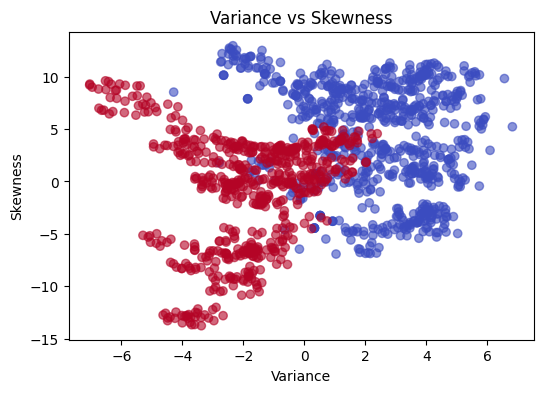

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df['variance'], df['skewness'], c=df['class'], cmap='coolwarm', alpha=0.6)
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance vs Skewness")
plt.show()

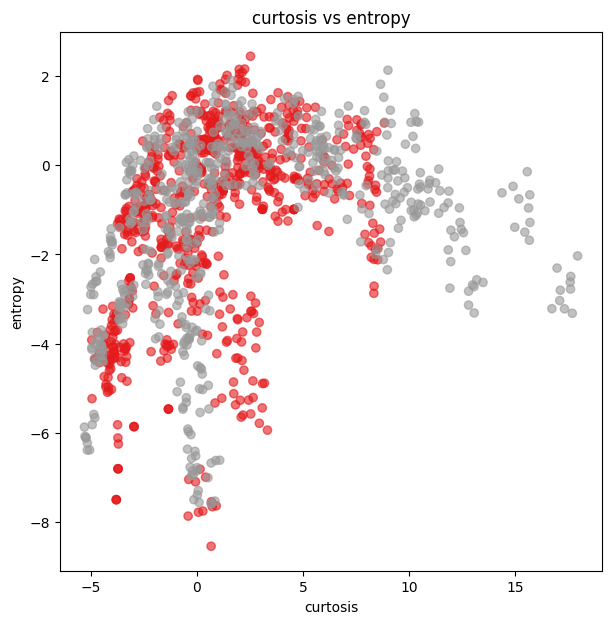

In [13]:
plt.figure(figsize=(7,7))
plt.scatter(df['curtosis'], df['entropy'], c=df['class'], cmap='Set1', alpha=0.6)
plt.xlabel("curtosis")
plt.ylabel("entropy")
plt.title("curtosis vs entropy")
plt.show()

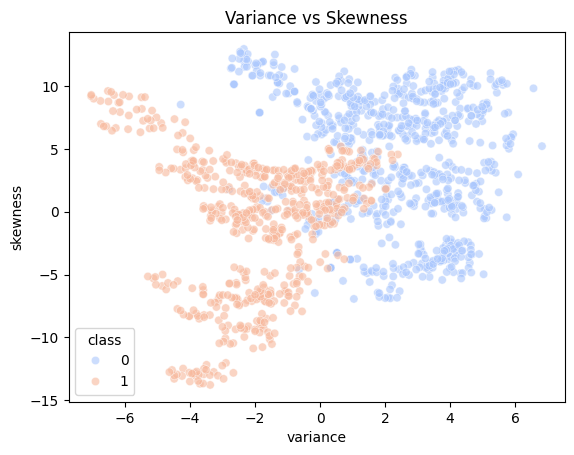

In [14]:
sns.scatterplot(x="variance", y="skewness", hue="class",
                data=df, palette="coolwarm", alpha=0.6)
plt.title("Variance vs Skewness")
plt.show()

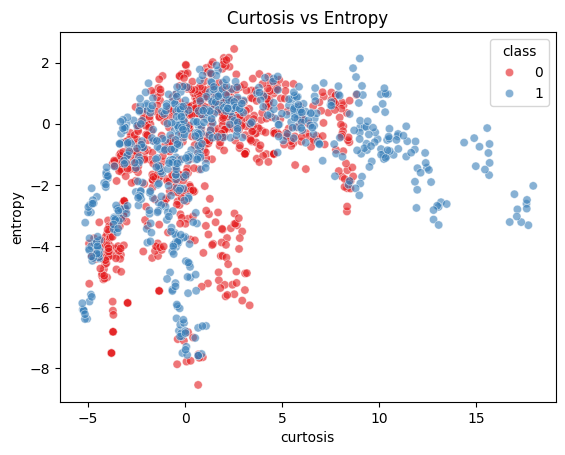

In [15]:
sns.scatterplot(x="curtosis", y="entropy", hue="class",
                data=df, palette="Set1", alpha=0.6)
plt.title("Curtosis vs Entropy")
plt.show()

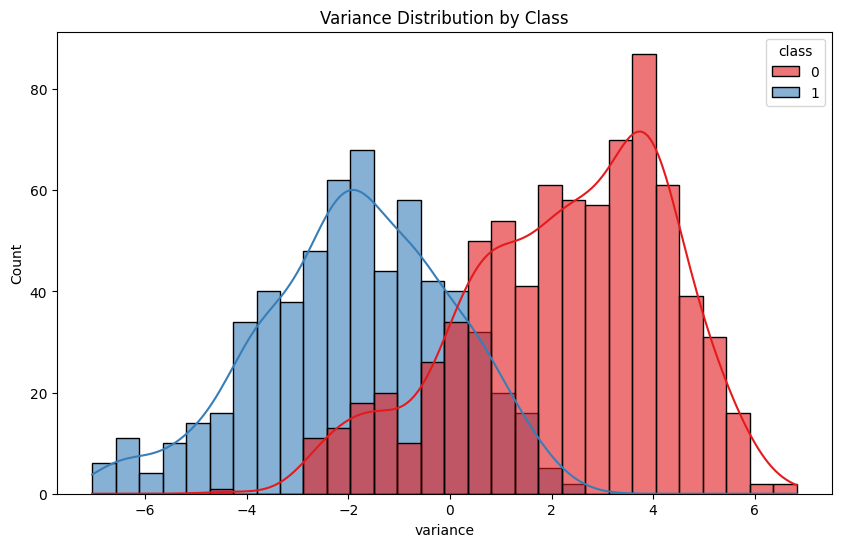

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="variance", hue="class", bins=30, kde=True, palette="Set1", alpha=0.6)
plt.title("Variance Distribution by Class")
plt.show()

In [17]:
X=df.drop('class',axis=1)
Y=df['class']

In [18]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=5)

#model training
model=LogisticRegression(class_weight='balanced',max_iter=1000)

model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
Y_pred=model.predict(X_test)
predicted_values=pd.DataFrame({'Actual':Y_test,'Predicted':Y_pred}).reset_index(drop=True)

In [21]:
predicted_values.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
5,0,0
6,1,1
7,1,1
8,1,1
9,0,0


In [22]:
#model evaluation in test data
accuracy_test = accuracy_score(Y_test, Y_pred)
conf_matrix_test = confusion_matrix(Y_test, Y_pred)
precision_test=precision_score(Y_test,Y_pred)
recall_test=recall_score(Y_test,Y_pred)


print("accuracy_score: ",accuracy_test)
print("confusionmatrix: \n",conf_matrix_test)
print("precision: ",precision_test)
print("recall: ",recall_test)

accuracy_score:  0.9941690962099126
confusionmatrix: 
 [[184   2]
 [  0 157]]
precision:  0.9874213836477987
recall:  1.0
